## 对图像的傅里叶变换

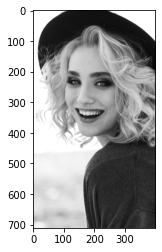

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 读取一张黑白图片
img_path = 'data/people.jpeg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.show()

<ipython-input-6-1c352307b3af>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img, dtype=torch.float32)


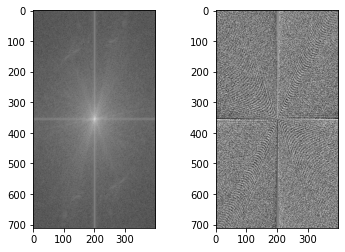

In [6]:
img = torch.tensor(img, dtype=torch.float32)

fft = torch.fft.fft2(img)
fft = torch.fft.fftshift(fft)  # 将低频部分移到中心

amplitude = torch.abs(fft)  # 取复数的绝对值
visual_amplitude = torch.log(1 + amplitude)
phase = torch.angle(fft)  # 取复数的相位角

a_min = torch.min(amplitude.flatten())
a_max = torch.max(amplitude.flatten())
amplitude_color = (amplitude - a_min) / (a_max - a_min) 
phase_color = (phase + np.pi) / (2 * np.pi) 

plt.subplot(1, 2, 1)
plt.imshow(visual_amplitude.numpy(), cmap='gray')
plt.imsave('result/amplitude.png', visual_amplitude.numpy(), cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(phase.numpy(), cmap='gray')
plt.imsave('result/phase.png', phase.numpy(), cmap='gray')
plt.show()

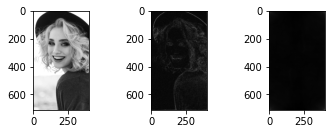

In [8]:
# 反变换

# 复原
fft1 = amplitude * torch.exp(1j * phase)
img1 = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(fft1)))

# 比较幅度谱和相位谱的重要性 
# 分别设定幅度为1，相位为0，观察反变换输出
fft2 = 1 * torch.exp(1j * phase)
fft3 = amplitude
img2 = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(fft2)))
img3 = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(fft3)))    


plt.subplot(2, 3, 1)
plt.imshow(img1.numpy(), cmap='gray')
plt.imsave('result/task3_origin.png', img1.numpy(), cmap='gray')
plt.subplot(2, 3, 2)
plt.imshow(img2.numpy(), cmap='gray')
plt.imsave('result/task3_amplitude1.png', img2.numpy(), cmap='gray')
plt.subplot(2, 3, 3)
plt.imshow(img3.numpy(), cmap='gray')
plt.imsave('result/task3_phase0.png', img3.numpy(), cmap='gray')
plt.show()

然后是滤波

tensor(17645.)


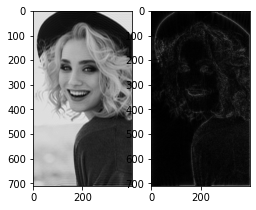

In [21]:
def low_pass_filter(shape, radius=100):
    h, w = shape
    cy, cx = h//2, w//2
    y = torch.arange(h).reshape(-1,1)
    x = torch.arange(w).reshape(1,-1)
    mask = ((y-cy)**2 + (x-cx)**2) < radius**2  # 圆形区域判断
    return mask.float()

mask = low_pass_filter(fft.shape, radius=75)
print(torch.sum(mask))
mask2 = 1 - mask
low_pass_filtered_fft = fft * mask
low_pass_filtered_ifft = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(low_pass_filtered_fft)))
high_pass_filtered_fft = fft * mask2
high_pass_filtered_ifft = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(high_pass_filtered_fft)))
# shaper_fft = fft + fft * mask2
# shaper_ifft = torch.abs(torch.fft.ifft2(shaper_fft))

plt.subplot(1, 3, 1)
plt.imshow(low_pass_filtered_ifft.numpy(), cmap='gray')
plt.imsave('result/task3_low_pass_filtered.png', low_pass_filtered_ifft.numpy(), cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(high_pass_filtered_ifft.numpy(), cmap='gray')
plt.imsave('result/task3_high_pass_filtered.png', high_pass_filtered_ifft.numpy(), cmap='gray')
# plt.subplot(1, 3, 3)
# plt.imshow(shaper_ifft.numpy(), cmap='gray')
# plt.imsave('result/task3_shaper_filtered.png', shaper_ifft.numpy(), cmap='gray')
plt.show()



下面想先看一下对彩色图片会怎样

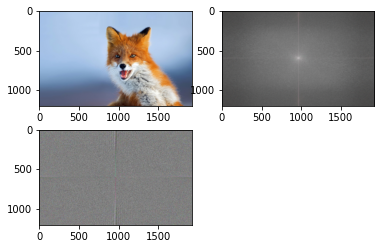

In [42]:
color_img_path = 'data/fox.jpg'
color_img = cv2.imread(color_img_path, cv2.IMREAD_COLOR_RGB)

plt.subplot(2, 2, 1)
plt.imshow(color_img)

color_img = torch.tensor(color_img).permute(2, 0, 1)
fft_color = torch.fft.fft2(color_img)
fft_color_shift = torch.fft.fftshift(fft_color)

amplitude_color = torch.log(1 + torch.abs(fft_color_shift)).permute(1, 2, 0)
phase_color = torch.angle(fft_color_shift).permute(1, 2, 0)
a_min = torch.min(amplitude_color.flatten())
a_max = torch.max(amplitude_color.flatten())
amplitude_color = (amplitude_color - a_min) / (a_max - a_min) 
phase_color = (phase_color + np.pi) / (2 * np.pi) 

plt.subplot(2, 2, 2)
plt.imshow(amplitude_color)
plt.imsave('result/task3_color_amplitude.png', amplitude_color.numpy())
plt.subplot(2, 2, 3)
plt.imshow(phase_color)
plt.imsave('result/task3_color_phase.png', phase_color.numpy())
plt.show()

时域卷积与频域卷积的速度差别

In [43]:
def time_conv(img, kernel):
    return torch.nn.functional.conv2d(img, kernel, padding='same')

def freq_conv(img, kernel):
    # 零填充保证尺寸
    img_pad = torch.nn.functional.pad(img, (0, kernel.shape[-1]-1, 0, kernel.shape[-2]-1))
    kernel_pad = torch.nn.functional.pad(kernel, (0, img.shape[-1]-1, 0, img.shape[-2]-1))
    
    # print(img_pad.shape, kernel_pad.shape)

    # 频域相乘
    img_fft = torch.fft.fft2(img_pad)
    kernel_fft = torch.fft.fft2(kernel_pad)
    result = torch.fft.ifft2(img_fft * kernel_fft).real
    
    # 裁剪有效区域
    return result[..., :img.shape[-2], :img.shape[-1]]

# 创建不同尺寸的卷积核
kernel3x3 = torch.randn(1,1,3,3)
kernel7x7 = torch.randn(1,1,7,7)
kernel15x15 = torch.randn(1,1,15,15)

img = img.view(1,1,*img.shape)
# 时域卷积
print('时域卷积: 3*3 7*7 15*15')
%timeit time_conv(img, kernel3x3)
%timeit time_conv(img, kernel7x7)
%timeit time_conv(img, kernel15x15) 

# 频域卷积
print('频域卷积: 3*3 7*7 15*15')
%timeit freq_conv(img, kernel3x3)
%timeit freq_conv(img, kernel7x7) 
%timeit freq_conv(img, kernel15x15) 

时域卷积: 3*3 7*7 15*15
710 µs ± 19.5 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
2.13 ms ± 103 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
154 ms ± 16.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
频域卷积: 3*3 7*7 15*15
6.9 ms ± 116 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
6.01 ms ± 122 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
6.15 ms ± 345 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [45]:
import torch
from torch.fft import fft2, ifft2

# 定义不同填充尺寸的FFT耗时测试
def test_fft_speed(size):
    x = torch.randn(size, size)
    %timeit fft2(x)

print("Size 258x258:")
test_fft_speed(258)  
print("\nSize 262x262:")
test_fft_speed(262)  
print("\nSize 270x270:")
test_fft_speed(270)  
print("\nSize 286x286:")
test_fft_speed(286)  

Size 258x258:
438 µs ± 11.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

Size 262x262:
343 µs ± 7.45 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

Size 270x270:
127 µs ± 1.62 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)

Size 286x286:
170 µs ± 3.3 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
